# Exploratory Data Analysis with Pyspark and Spark SQL

The following notebook utilizes New York City taxi data from [TLC Trip Record Data](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page)

## Instructions

- Load and explore nyc taxi data from january 0f 2019. The exercises can be executed using pyspark or spark sql (a subset of the questions will be re-answered using the language not chosen for the  main work).
- Load the zone lookup table to answer the questions about the nyc boroughs.  
- Load nyc taxi data from January of 2025 and compare data.  
- With any remaining time, work on the where to go from here section.
- Note: the initial lab is opened as read only. To save work completed utilize the `save notebook as` option and give the lab a new name.

In [1]:
# Google Colab: pyspark is not preinstalled (skip this cell on the Docker image)
!pip install -q pyspark

In [2]:
import requests

# start a spark session and create a spark context
from pyspark.sql import SparkSession
spark = SparkSession.builder \
    .appName("nyc_taxi") \
    .getOrCreate()

sc = spark.sparkContext

In [3]:
# set dl url for January 2019 trip data
download_url = 'https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2019-01.parquet'

# get the data
response = requests.get(download_url)

# check that response was good and save the data
jan_2019_trip_data = "yellow_tripdata_2019-01.parquet"
if response.status_code == 200:
    # Changed 'response' to 'data' here
    with open(jan_2019_trip_data, "wb") as f:
        f.write(response.content)


In [4]:
# create the dataframe
df_trips = spark.read.parquet(jan_2019_trip_data)

# A brief note on handling data sources in spark

The command above works well for loading data from parquet files because parquet is a self descibing file format, meaning that the metadata needed to build the dataframe is included directly in the format. However, when working with other formats such as csv or json, a schema must be provided or infered. In production code the schema should always be explicitly provided but during the data exploration phase it is acceptable to infer the schema, and when infering the schema it often best to use `.option("samplingRatio", <small-portion-of-data>)` to avoid using the entire dataset for schema inference.

```python
df_trips = spark.read.format("csv") \
    .option("header", "true") \
    .option("sep", ",") \
    .option("samplingRatio", 0.01) \
    .load("large_dataset.csv")
```

In [5]:
# Show the dataframe
df_trips.show()

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|airport_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|       1| 2019-01-01 00:46:40|  2019-01-01 00:53:20|            1.0|          1.5|       1.0|                 N|         151|         239|           1|        7.0|  0.5|    0.5|      1.6

## Lab

### Part 1
This section can be completed either using pyspark commands or sql commands ( There will be a section after in which a self-chosen subset of the questions are re-answered using the language not used for the main section. i.e. if pyspark is chosen for the main lab, sql should be used to repeat some of the questions. )

- Add a column that creates a unique key to identify each record in order to answer questions about individual trips
- Which trip has the highest passanger count
- What is the Average passanger count
- Shortest/longest trip by distance? by time?.
- busiest day/slowest single day
- busiest/slowest time of day ( you may want to bucket these by hour or create timess such as morning, afternoon, evening, late night )
- On average which day of the week is slowest/busiest
- Does trip distance or num passangers affect tip amount
- What was the highest "extra" charge and which trip
- Are there any datapoints that seem to be strange/outliers (make sure to explain your reasoning in a markdown cell)?

**Setup** — imports and restriction to January 2019 trips (the file contains a few stray rows from other months).

In [6]:
from pyspark.sql import functions as F
# The file contains a few stray rows dated outside January 2019 (Dec 2018, Feb-Aug 2019).
# We restrict the dataset to the studied month so that per-day statistics are correct.
n_raw = df_trips.count()
df_trips = df_trips.filter(
    (F.col("tpep_pickup_datetime") >= "2019-01-01") &
    (F.col("tpep_pickup_datetime") < "2019-02-01")
)
print(f"Raw rows: {n_raw:,}  ->  January 2019: {df_trips.count():,}")

Raw rows: 7,696,617  ->  January 2019: 7,696,080


> **Q1.** Add a column that creates a unique key to identify each record in order to answer questions about individual trips

In [7]:
# 1.unique key
df_trips = df_trips.withColumn("trip_id", F.monotonically_increasing_id())
df_trips.select("trip_id", "tpep_pickup_datetime", "trip_distance", "fare_amount").show(5)

+-------+--------------------+-------------+-----------+
|trip_id|tpep_pickup_datetime|trip_distance|fare_amount|
+-------+--------------------+-------------+-----------+
|      0| 2019-01-01 00:46:40|          1.5|        7.0|
|      1| 2019-01-01 00:59:47|          2.6|       14.0|
|      2| 2019-01-01 00:21:28|          1.3|        6.5|
|      3| 2019-01-01 00:32:01|          3.7|       13.5|
|      4| 2019-01-01 00:57:32|          2.1|       10.0|
+-------+--------------------+-------------+-----------+
only showing top 5 rows


> **Q2.** Which trip has the highest passenger count

In [8]:
# 2.highest passenger count
df_trips.orderBy(F.col("passenger_count").desc()).select("trip_id", "passenger_count").show(1)

+-------+---------------+
|trip_id|passenger_count|
+-------+---------------+
| 949579|            9.0|
+-------+---------------+
only showing top 1 row


> **Q3.** What is the average passenger count

In [9]:
# 3. average passenger count
df_trips.select(F.avg("passenger_count").alias("avg_passengers")).show()

+------------------+
|    avg_passengers|
+------------------+
|1.5670089553079738|
+------------------+



> **Q4.** Shortest/longest trip by distance? by time?

In [10]:
# 4.duration in minutes (unix_timestamp)
df_trips = df_trips.withColumn(
    "duration_min",
    (F.unix_timestamp("tpep_dropoff_datetime") - F.unix_timestamp("tpep_pickup_datetime")) / 60
)

print("--- Distance min / max (raw data) ---")
df_trips.orderBy("trip_distance").select("trip_id", "trip_distance").show(1)
df_trips.orderBy(F.col("trip_distance").desc()).select("trip_id", "trip_distance").show(1)

print("--- Duration min / max in minutes (raw data) ---")
df_trips.orderBy("duration_min").select("trip_id", "duration_min").show(1)
df_trips.orderBy(F.col("duration_min").desc()).select("trip_id", "duration_min").show(1)

--- Distance min / max (raw data) ---
+-------+-------------+
|trip_id|trip_distance|
+-------+-------------+
|    452|          0.0|
+-------+-------------+
only showing top 1 row
+-------+-------------+
|trip_id|trip_distance|
+-------+-------------+
|6073622|        831.8|
+-------+-------------+
only showing top 1 row
--- Duration min / max in minutes (raw data) ---
+-------+------------+
|trip_id|duration_min|
+-------+------------+
|1202807|    -84280.5|
+-------+------------+
only showing top 1 row
+-------+-----------------+
|trip_id|     duration_min|
+-------+-----------------+
|  67966|43648.01666666667|
+-------+-----------------+
only showing top 1 row


In [11]:
#raw values are outliers (0 distance, negative or multi-day duration).
# recompute min / max on plausible trips: distance > 0, 0 < duration < 24 h.
df_valid = df_trips.filter(
    (F.col("trip_distance") > 0) &
    (F.col("duration_min") > 0) & (F.col("duration_min") < 24 * 60)
)

print("--- Distance min / max (plausible trips) ---")
df_valid.orderBy("trip_distance").select("trip_id", "trip_distance", "duration_min").show(1)
df_valid.orderBy(F.col("trip_distance").desc()).select("trip_id", "trip_distance", "duration_min").show(1)

print("--- Duration min / max (plausible trips) ---")
df_valid.orderBy("duration_min").select("trip_id", "trip_distance", "duration_min").show(1)
df_valid.orderBy(F.col("duration_min").desc()).select("trip_id", "trip_distance", "duration_min").show(1)

--- Distance min / max (plausible trips) ---
+-------+-------------+-------------------+
|trip_id|trip_distance|       duration_min|
+-------+-------------+-------------------+
|  12423|         0.01|0.06666666666666667|
+-------+-------------+-------------------+
only showing top 1 row
+-------+-------------+-----------------+
|trip_id|trip_distance|     duration_min|
+-------+-------------+-----------------+
|6073622|        831.8|9.483333333333333|
+-------+-------------+-----------------+
only showing top 1 row
--- Duration min / max (plausible trips) ---
+-------+-------------+--------------------+
|trip_id|trip_distance|        duration_min|
+-------+-------------+--------------------+
|  51905|         1.65|0.016666666666666666|
+-------+-------------+--------------------+
only showing top 1 row
+-------+-------------+------------------+
|trip_id|trip_distance|      duration_min|
+-------+-------------+------------------+
|3310705|        18.61|1439.9833333333333|
+-------+-----

The raw min/max are useless : 0 mile means the meter was never started, the negative duration (-84 280 min) is a dropoff time before the pickup time so it's a bug of the terminal, and 43 648 min is 30 days so the meter was just never closed. When we keep only the trips that make sense (distance > 0, duration between 0 and 24h) the shortest trip is 0.01 mile in 4 seconds (someone who get out directly) and the shortest duration is 1 second for 1.65 mile, so still a bug. For the longest, the filter is not enough : 831.8 miles in 9 minutes is impossible (5 000 mph !) so it's an error too, and the longest duration is 1 439.98 min = exactly 24h for 18 miles, probably a meter left open. To have the real longest trip we should also filter on the speed (distance / duration), for example less than 100 mph.

> **Q5.** Busiest day / slowest single day

In [12]:
# 5. busiest / slowest day of January
df_days = df_trips.withColumn("date", F.to_date("tpep_pickup_datetime")) \
    .groupBy("date").count()
print("Top 5 busiest days:")
df_days.orderBy(F.col("count").desc()).show(5)
print("Top 5 slowest days:")
df_days.orderBy(F.col("count").asc()).show(5)

Top 5 busiest days:
+----------+------+
|      date| count|
+----------+------+
|2019-01-25|292499|
|2019-01-11|291714|
|2019-01-31|284625|
|2019-01-17|284580|
|2019-01-24|281959|
+----------+------+
only showing top 5 rows
Top 5 slowest days:
+----------+------+
|      date| count|
+----------+------+
|2019-01-01|189432|
|2019-01-21|192826|
|2019-01-02|198737|
|2019-01-20|203114|
|2019-01-06|208823|
+----------+------+
only showing top 5 rows


Busiest day is friday 25 january with 292 499 trips, then friday 11 and thursday 31 : end of the week, people go out and come back late. Slowest day is the 1st january with 189 432 trips (holiday, everybody sleeps after new year eve), then the 21 and 20 january : it's the martin luther king week end and also the polar vortex days, very cold in NYC so people stay at home.

> **Q6.** Busiest/slowest time of day (bucketed by hour, then by period: morning, afternoon, evening, late night)

In [13]:
# 6.trips by hour of the day
df_hours = df_trips.withColumn("hour", F.hour("tpep_pickup_datetime")).groupBy("hour").count()

print("Busiest hours:")
df_hours.orderBy(F.col("count").desc()).show(5)
print("Slowest hours:")
df_hours.orderBy(F.col("count").asc()).show(5)

#bucketing into periods of the day
df_periods = df_trips.withColumn("hour", F.hour("tpep_pickup_datetime")) \
    .withColumn("period",
        F.when(F.col("hour").between(5, 11), "morning")
         .when(F.col("hour").between(12, 16), "afternoon")
         .when(F.col("hour").between(17, 21), "evening")
         .otherwise("late night")) \
    .groupBy("period").count().orderBy(F.col("count").desc())
df_periods.show()

Busiest hours:
+----+------+
|hour| count|
+----+------+
|  18|515374|
|  19|475152|
|  17|468407|
|  15|452679|
|  14|433115|
+----+------+
only showing top 5 rows
Slowest hours:
+----+------+
|hour| count|
+----+------+
|   4| 61423|
|   5| 75532|
|   3| 78084|
|   2|109413|
|   1|149242|
+----+------+
only showing top 5 rows
+----------+-------+
|    period|  count|
+----------+-------+
|   evening|2291934|
| afternoon|2111921|
|   morning|2035467|
|late night|1256758|
+----------+-------+



Peak hour is 18h with around 515 000 trips in the month, then 19h and 17h : it's the end of the office. The slowest hour is 4h in the morning (around 61 000), after the night and before the commute. By period the evening (17h-21h) is first, then afternoon, morning and late night. The buckets are easier to read but we lose the big peak of 18h-19h.

> **Q7.** On average which day of the week is slowest/busiest

In [14]:
# 7.Day of the week: total AND average per day
# (January 2019 has  5 Tuesdays/Wednesdays/Thursdays but 4 Mondays/Fridays/Saturdays/Sundays:
#  divide by the number of occurrences to compare "on average")
df_dow = df_trips.withColumn("date", F.to_date("tpep_pickup_datetime")) \
    .withColumn("day_of_week", F.date_format("tpep_pickup_datetime", "EEEE")) \
    .groupBy("day_of_week").agg(
        F.count("*").alias("total_trips"),
        F.countDistinct("date").alias("n_days")
    ).withColumn("avg_trips_per_day", F.col("total_trips") / F.col("n_days"))
df_dow.orderBy(F.col("avg_trips_per_day").desc()).show()

+-----------+-----------+------+-----------------+
|day_of_week|total_trips|n_days|avg_trips_per_day|
+-----------+-----------+------+-----------------+
|     Friday|    1087150|     4|         271787.5|
|   Thursday|    1356992|     5|         271398.4|
|  Wednesday|    1265229|     5|         253045.8|
|   Saturday|    1009979|     4|        252494.75|
|    Tuesday|    1209076|     5|         241815.2|
|     Monday|     907764|     4|         226941.0|
|     Sunday|     859890|     4|         214972.5|
+-----------+-----------+------+-----------------+



With the total, thursday is the busiest and sunday the slowest. But january 2019 has 5 tuesdays, wednesdays and thursdays and only 4 of the other days, so it's not fair ! With the average per day, friday becomes the busiest (271 787 trips per day) just in front of thursday (271 398), and the saturday goes up too. Sunday stays clearly the slowest (214 972). So the answer changes : on average the busiest day is friday, not thursday. The average per day is the good way to answer "on average".

> **Q8.** Does trip distance or number of passengers affect tip amount

In [15]:
# 8. Effect of distance / passengers on the tip
print("Correlation distance / tip:", df_trips.stat.corr("trip_distance", "tip_amount"))
print("Correlation passengers / tip:", df_trips.stat.corr("passenger_count", "tip_amount"))
# Average tip by passenger count
df_trips.groupBy("passenger_count").agg(
    F.avg("tip_amount").alias("avg_tip"), F.count("*").alias("n")
).orderBy("passenger_count").show()

Correlation distance / tip: 0.5269460290274736
Correlation passengers / tip: 0.004426230205403716
+---------------+--------------------+-------+
|passenger_count|             avg_tip|      n|
+---------------+--------------------+-------+
|           NULL|0.061789899553571406|  28672|
|            0.0|  1.7869007761051638| 117381|
|            1.0|  1.8283797977982486|5456177|
|            2.0|  1.8339551479007163|1113794|
|            3.0|  1.7956389567716011| 314677|
|            4.0|  1.7023888221793764| 140743|
|            5.0|  1.8699418452025662| 323791|
|            6.0|  1.8567878060442715| 200788|
|            7.0|   6.542631578947368|     19|
|            8.0|   6.480689655172414|     29|
|            9.0|  3.1166666666666667|      9|
+---------------+--------------------+-------+



Correlation between distance and tip is 0.53 so it's strong, logic because the tip is a % of the price and the price depends on the distance. Correlation between passengers and tip is 0.004 so nothing : the average tip is the same with 1 or 5 passengers, the others don't pay more. Also tip_amount is only for card payment (payment_type = 1), cash tips are not in the data, so the amounts are under estimated but the conclusion is the same.

> **Q9.** What was the highest "extra" charge and which trip

In [16]:
# 9 Highest extra
df_trips.orderBy(F.col("extra").desc()) \
    .select("trip_id", "extra", "fare_amount", "total_amount", "trip_distance", "tpep_pickup_datetime").show(1)

+-------+------+-----------+------------+-------------+--------------------+
|trip_id| extra|fare_amount|total_amount|trip_distance|tpep_pickup_datetime|
+-------+------+-----------+------------+-------------+--------------------+
|5323019|535.38|  355676.98|   356214.78|          0.0| 2019-01-23 08:58:09|
+-------+------+-----------+------------+-------------+--------------------+
only showing top 1 row


Highest extra is 535.38 $ but the real extras are only 0.50 $ (night) or 1 $ (rush hour). The fare of this trip is around 355 677 $ for a few miles so it's clearly an error of typing (no decimal point), not a real trip. We have to remove this line before doing stats on the amounts.

> **Q10.** Are there any datapoints that seem to be strange/outliers? (reasoning in the markdown cells below)

In [17]:
# 10 counting suspicious values
print("Distance = 0:", df_trips.filter(F.col("trip_distance") == 0).count())
print("Distance > 100 miles:", df_trips.filter(F.col("trip_distance") > 100).count())
print("Duration <= 0:", df_trips.filter(F.col("duration_min") <= 0).count())
print("Duration > 3 h:", df_trips.filter(F.col("duration_min") > 180).count())
print("fare_amount < 0:", df_trips.filter(F.col("fare_amount") < 0).count())
print("fare_amount > $500:", df_trips.filter(F.col("fare_amount") > 500).count())
print("passenger_count = 0:", df_trips.filter(F.col("passenger_count") == 0).count())
print("passenger_count > 6:", df_trips.filter(F.col("passenger_count") > 6).count())

df_trips.select("trip_distance", "duration_min", "fare_amount", "tip_amount", "extra", "passenger_count") \
    .summary("min", "25%", "50%", "75%", "max").show()

Distance = 0: 55060
Distance > 100 miles: 32
Duration <= 0: 6554
Duration > 3 h: 20843
fare_amount < 0: 7129
fare_amount > $500: 34
passenger_count = 0: 117381
passenger_count > 6: 57
+-------+-------------+------------------+-----------+----------+------+---------------+
|summary|trip_distance|      duration_min|fare_amount|tip_amount| extra|passenger_count|
+-------+-------------+------------------+-----------+----------+------+---------------+
|    min|          0.0|          -84280.5|     -362.0|     -63.5| -60.0|            0.0|
|    25%|          0.9|               6.1|        6.0|       0.0|   0.0|            1.0|
|    50%|         1.54|10.183333333333334|        9.0|       1.4|   0.0|            1.0|
|    75%|         2.83|             16.65|       13.5|      2.32|   0.5|            2.0|
|    max|        831.8| 43648.01666666667|  623259.86|    787.25|535.38|            9.0|
+-------+-------------+------------------+-----------+----------+------+---------------+



**Outlier analysis:**

- **Abnormal maximum distance**: a maximum distance of 831.8 miles for a single urban taxi trip is an extreme outlier.
- **Zero distances**: many trips record a distance of 0.0 miles while still having a charged amount.
- **Abnormal fares and extras**: one trip shows an "extra" charge of $535.38 for a total fare above $355,000, which corresponds to a data-entry or system error.
- **Passenger count**: values go up to 9 passengers (beyond the standard capacity of a yellow cab) or down to 0 passengers.

In addition to the list above we also found : negative or zero durations (dropoff before pickup, clock error of the terminal) and durations of several days (meter never closed) ; negative fares (down to -362 $), in fact they are refunds or cancellations saved as negative ; a max fare of 623 259 $ and a total of 355 000 $, impossible for a taxi ; and some dates outside january 2019 (december 2018, february to august 2019, just a few lines) that we removed at the beginning of the notebook. Our reasoning : we separate the impossible (negative duration, 0 distance with a price, 831 miles in the city, 9 passengers in a car) from the unlikely but possible (100 miles to a far airport, a very big tip). The first ones are errors so we remove them, the second ones we keep but we watch them because they change a lot the averages (see the 2025 distance below).

### Part 2

- Using the code for loading the first dataset as an example, load in the taxi zone lookup and answer the following questions
- which borough had most pickups? dropoffs?
- what are the busy/slow times by borough
- what are the busiest days of the week by borough?
- what is the average trip distance by borough?
- what is the average trip fare by borough?
- highest/lowest faire amounts for a trip, what burough is associated with the each
- load the dataset from the most recently available january, is there a change to any of the average metrics.

> **Setup.** Using the code for loading the first dataset as an example, load in the taxi zone lookup (then join it to the trips on pickup and dropoff location IDs)

In [18]:
import requests
from pyspark.sql import Window
# Download and load the taxi zone lookup table
zone_url = 'https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv'
res_zone = requests.get(zone_url)
if res_zone.status_code == 200:
    with open("taxi_zone_lookup.csv", "wb") as f:
        f.write(res_zone.content)
df_zones = spark.read.csv("taxi_zone_lookup.csv", header=True, inferSchema=True)
df_zones.show(5)

# Joins to the map location IDs to boroughs
df_joined = df_trips.join(df_zones, df_trips.PULocationID == df_zones.LocationID, "left") \
    .withColumnRenamed("Borough", "PUBorough") \
    .withColumnRenamed("Zone", "PUZone") \
    .drop("LocationID", "service_zone")
df_joined = df_joined.join(df_zones, df_joined.DOLocationID == df_zones.LocationID, "left") \
    .withColumnRenamed("Borough", "DOBorough") \
    .withColumnRenamed("Zone", "DOZone") \
    .drop("LocationID", "service_zone")

+----------+-------------+--------------------+------------+
|LocationID|      Borough|                Zone|service_zone|
+----------+-------------+--------------------+------------+
|         1|          EWR|      Newark Airport|         EWR|
|         2|       Queens|         Jamaica Bay|   Boro Zone|
|         3|        Bronx|Allerton/Pelham G...|   Boro Zone|
|         4|    Manhattan|       Alphabet City| Yellow Zone|
|         5|Staten Island|       Arden Heights|   Boro Zone|
+----------+-------------+--------------------+------------+
only showing top 5 rows


> **Q1.** Which borough had most pickups? dropoffs?

In [19]:
print("--- Pickups by borough ---")
df_joined.groupBy("PUBorough").count().orderBy(F.col("count").desc()).show()
print("--- Dropoffs by borough ---")
df_joined.groupBy("DOBorough").count().orderBy(F.col("count").desc()).show()

--- Pickups by borough ---
+-------------+-------+
|    PUBorough|  count|
+-------------+-------+
|    Manhattan|6950511|
|       Queens| 471113|
|      Unknown| 159807|
|     Brooklyn|  91896|
|        Bronx|  18056|
|          N/A|   3890|
|          EWR|    446|
|Staten Island|    361|
+-------------+-------+

--- Dropoffs by borough ---
+-------------+-------+
|    DOBorough|  count|
+-------------+-------+
|    Manhattan|6816936|
|       Queens| 340914|
|     Brooklyn| 301074|
|      Unknown| 149091|
|        Bronx|  58068|
|          N/A|  16900|
|          EWR|  10913|
|Staten Island|   2184|
+-------------+-------+



Manhattan takes almost everything : around 6.95M pickups and 6.82M dropoffs on 7.7M trips so 90 %. Queens is far behind (471k pickups, mostly the airports JFK and LaGuardia). The interesting thing is Brooklyn : 3 times more dropoffs (301k) than pickups (92k), same for the Bronx (58k vs 18k). People take a yellow taxi to go home from Manhattan but they don't take one from their neighbourhood, there the yellow taxis don't drive, it's the green taxis and Uber.

> **Q2.** What are the busy/slow times by borough

In [20]:
df_hourly = df_joined.withColumn("hour", F.hour("tpep_pickup_datetime")) \
    .groupBy("PUBorough", "hour").count()

w_desc = Window.partitionBy("PUBorough").orderBy(F.col("count").desc())
w_asc = Window.partitionBy("PUBorough").orderBy(F.col("count").asc())

print("Busiest hour by borough is:")
df_hourly.withColumn("rank", F.row_number().over(w_desc)) \
    .filter(F.col("rank") == 1).drop("rank") \
    .orderBy("PUBorough").show(10)
print("Slowest hour by borough is:")
df_hourly.withColumn("rank", F.row_number().over(w_asc)) \
    .filter(F.col("rank") == 1).drop("rank") \
    .orderBy("PUBorough").show(10)

Busiest hour by borough is:
+-------------+----+------+
|    PUBorough|hour| count|
+-------------+----+------+
|        Bronx|   7|  1803|
|     Brooklyn|   8|  6935|
|          EWR|  15|    54|
|    Manhattan|  18|471524|
|          N/A|  19|   214|
|       Queens|  16| 29880|
|Staten Island|   8|    36|
|      Unknown|  18| 10751|
+-------------+----+------+

Slowest hour by borough is:
+-------------+----+-----+
|    PUBorough|hour|count|
+-------------+----+-----+
|        Bronx|   3|  225|
|     Brooklyn|   3| 1919|
|          EWR|  23|    1|
|    Manhattan|   4|53446|
|          N/A|   6|   88|
|       Queens|   3| 3084|
|Staten Island|   1|    3|
|      Unknown|   4| 1465|
+-------------+----+-----+



In Manhattan the peak is 18h (end of office, 471k trips in the month) and the slowest is 4h. In the Bronx, Brooklyn and Staten Island the peak is in the morning 7h-8h : it's people going to work in Manhattan. Queens peak is 16h, it matches the arrivals of the planes at JFK/LaGuardia. EWR (Newark) is very small. Slow hours are between 1h and 4h everywhere.

> **Q3.** What are the busiest days of the week by borough?

In [21]:
df_dow_borough = df_joined.withColumn(
        "day_of_week", F.date_format("tpep_pickup_datetime", "EEEE")
    ).groupBy("PUBorough", "day_of_week").count()

w_dow = Window.partitionBy("PUBorough").orderBy(F.col("count").desc())

df_dow_borough.withColumn("rank", F.row_number().over(w_dow)) \
    .filter(F.col("rank") == 1).drop("rank") \
    .orderBy("PUBorough").show(10)

+-------------+-----------+-------+
|    PUBorough|day_of_week|  count|
+-------------+-----------+-------+
|        Bronx|   Thursday|   3121|
|     Brooklyn|    Tuesday|  15779|
|          EWR|  Wednesday|     83|
|    Manhattan|   Thursday|1229516|
|          N/A|    Tuesday|    703|
|       Queens|   Thursday|  78961|
|Staten Island|     Friday|     64|
|      Unknown|   Thursday|  28927|
+-------------+-----------+-------+



> **Q4 & Q5.** What is the average trip distance by borough? What is the average trip fare by borough?

In [22]:
df_joined.groupBy("PUBorough").agg(
    F.avg("trip_distance").alias("avg_distance"),
    F.avg("fare_amount").alias("avg_fare"),
    F.count("*").alias("n_trips")
).orderBy(F.col("avg_fare").desc()).show()

+-------------+------------------+------------------+-------+
|    PUBorough|      avg_distance|          avg_fare|n_trips|
+-------------+------------------+------------------+-------+
|          EWR| 2.641098654708519| 76.24024663677126|    446|
|          N/A| 3.193850899742941|  59.5731593830335|   3890|
|Staten Island|12.503601108033246|45.289861495844896|    361|
|       Queens|11.283685060696447|35.144710419789384| 471113|
|        Bronx| 7.234111098803697|26.270240917147586|  18056|
|     Brooklyn|   4.7876346086881| 18.64909843736217|  91896|
|      Unknown| 2.415580669182199| 14.94432265169866| 159807|
|    Manhattan|2.2286369894240687|  10.7923875395659|6950511|
+-------------+------------------+------------------+-------+



Manhattan = short and cheap trips (2.2 miles, 10.8 $) because the traffic is dense and people move inside the same area. Queens (11.3 mi / 35 $) and Staten Island (12.5 mi / 45 $) have the longest trips : airports and suburbs to Manhattan. EWR has a small distance but the biggest fare (76 $) because Newark <-> Manhattan is a fixed price plus the tolls. Bronx and Brooklyn are in the middle (7 mi / 26 $ and 4.8 mi / 19 $).

> **Q6.** Highest/lowest fare amounts for a trip, what borough is associated with each

In [23]:
print("--- Highest fare (raw) ---")
df_joined.orderBy(F.col("fare_amount").desc()) \
    .select("trip_id", "fare_amount", "trip_distance", "PUBorough", "DOBorough").show(1)

print("--- Lowest fare (raw) ---")
df_joined.orderBy(F.col("fare_amount").asc()) \
    .select("trip_id", "fare_amount", "trip_distance", "PUBorough", "DOBorough").show(1)

print("--- Highest fare among plausible trips (fare > 0, distance > 0, fare < $500) ---")
df_joined.filter((F.col("fare_amount") > 0) & (F.col("trip_distance") > 0) & (F.col("fare_amount") < 500)) \
    .orderBy(F.col("fare_amount").desc()) \
    .select("trip_id", "fare_amount", "trip_distance", "PUBorough", "DOBorough").show(1)

--- Highest fare (raw) ---
+-------+-----------+-------------+---------+---------+
|trip_id|fare_amount|trip_distance|PUBorough|DOBorough|
+-------+-----------+-------------+---------+---------+
|2499263|  623259.86|          2.4|Manhattan|Manhattan|
+-------+-----------+-------------+---------+---------+
only showing top 1 row
--- Lowest fare (raw) ---
+-------+-----------+-------------+---------+---------+
|trip_id|fare_amount|trip_distance|PUBorough|DOBorough|
+-------+-----------+-------------+---------+---------+
|4890185|     -362.0|          0.0|   Queens|   Queens|
+-------+-----------+-------------+---------+---------+
only showing top 1 row
--- Highest fare among plausible trips (fare > 0, distance > 0, fare < $500) ---
+-------+-----------+-------------+---------+---------+
|trip_id|fare_amount|trip_distance|PUBorough|DOBorough|
+-------+-----------+-------------+---------+---------+
|1368686|      498.0|        108.5|   Queens|      N/A|
+-------+-----------+-------------+-

The raw max fare is 623 259.86 $ for Manhattan -> Manhattan (2.4 miles !) and the min is -362 $ for Queens -> Queens, both are errors : the first is a wrong typing and the second is a refund saved as negative. With only the trips that make sense (fare between 0 and 500 $, distance > 0) the highest fare is 498 $ for a trip of 108.5 miles from Queens (airport) to an unknown zone (N/A), so outside the city, it's a real long trip.

> **Q7.** Load the dataset from the most recently available January, is there a change to any of the average metrics?

In [24]:
# Load January 2025 and compare metrics
jan_2025_url = 'https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2025-01.parquet'
res_2025 = requests.get(jan_2025_url)
if res_2025.status_code == 200:
    with open("yellow_tripdata_2025-01.parquet", "wb") as f:
        f.write(res_2025.content)

df_2025 = spark.read.parquet("yellow_tripdata_2025-01.parquet") \
    .filter((F.col("tpep_pickup_datetime") >= "2025-01-01") & (F.col("tpep_pickup_datetime") < "2025-02-01"))

metrics = [F.count("*").alias("n_trips"),
           F.avg("fare_amount").alias("avg_fare"),
           F.avg("trip_distance").alias("avg_distance"),
           F.avg("passenger_count").alias("avg_passengers"),
           F.avg("tip_amount").alias("avg_tip")]

print("January 2019:")
df_trips.select(*metrics).show()
print("January 2025:")
df_2025.select(*metrics).show()

# Same comparison without outlier distances (> 100 miles)
print("Average distance without outliers (< 100 miles):")
print("  2019:", df_trips.filter(F.col("trip_distance") < 100).select(F.avg("trip_distance")).first()[0])
print("  2025:", df_2025.filter(F.col("trip_distance") < 100).select(F.avg("trip_distance")).first()[0])

January 2019:
+-------+-----------------+-----------------+------------------+------------------+
|n_trips|         avg_fare|     avg_distance|    avg_passengers|           avg_tip|
+-------+-----------------+-----------------+------------------+------------------+
|7696080|12.52951516096942|2.830113865760418|1.5670089553079738|1.8208502016665093|
+-------+-----------------+-----------------+------------------+------------------+

January 2025:
+-------+------------------+------------------+-----------------+------------------+
|n_trips|          avg_fare|      avg_distance|   avg_passengers|           avg_tip|
+-------+------------------+------------------+-----------------+------------------+
|3475204|17.081793465940684|5.8551408435294325|1.297854725039224|2.9598042014220503|
+-------+------------------+------------------+-----------------+------------------+

Average distance without outliers (< 100 miles):
  2019: 2.829429355170518
  2025: 3.094531096314131


Between january 2019 and january 2025 the number of trips is divided by 2 (7.7M -> around 3.5M) : Uber/Lyft and the COVID effect on the yellow taxis. The average fare goes from 12.5 $ to around 17 $ (+36 %), it's the official increase of the TLC in december 2022. The average passengers goes down (1.57 -> 1.30) so more people alone. The average distance looks like it doubles (2.8 -> 5.9 mi) but it's mostly because of the outliers in the 2025 file : without the outliers (< 100 miles) it increases much less. So some short trips went to Uber but the distance is not really x2.

### Part 3

- choose 3 questions from above and re-answer them using the language you did not use for the main notebook . (i.e - if you completed the exercise in python, redo 3 questions in pure sql) . at least one of the questions to be redone must involve a join

The main lab was done with PySpark; we re-answer 3 questions in Spark SQL, including one with a join.

In [25]:
# 1. Create temporary SQL views
df_trips.createOrReplaceTempView("trips_2019")
df_zones.createOrReplaceTempView("zones")

> **SQL 1.** Average passenger count (Part 1, Q3)

In [26]:
spark.sql("SELECT AVG(passenger_count) AS avg_passengers FROM trips_2019").show()

+------------------+
|    avg_passengers|
+------------------+
|1.5670089553079738|
+------------------+



> **SQL 2.** Trips by day of the week (Part 1, Q7)

In [27]:
spark.sql('''
    SELECT date_format(tpep_pickup_datetime, 'EEEE') AS day_of_week,
           COUNT(*) AS total_trips,
           COUNT(DISTINCT to_date(tpep_pickup_datetime)) AS n_days,
           COUNT(*) / COUNT(DISTINCT to_date(tpep_pickup_datetime)) AS avg_trips_per_day
    FROM trips_2019
    GROUP BY day_of_week
    ORDER BY avg_trips_per_day DESC
''').show()

+-----------+-----------+------+-----------------+
|day_of_week|total_trips|n_days|avg_trips_per_day|
+-----------+-----------+------+-----------------+
|     Friday|    1087150|     4|         271787.5|
|   Thursday|    1356992|     5|         271398.4|
|  Wednesday|    1265229|     5|         253045.8|
|   Saturday|    1009979|     4|        252494.75|
|    Tuesday|    1209076|     5|         241815.2|
|     Monday|     907764|     4|         226941.0|
|     Sunday|     859890|     4|         214972.5|
+-----------+-----------+------+-----------------+



> **SQL 3 (with JOIN).** Pickups by borough (Part 2, Q1)

In [28]:
spark.sql('''
    SELECT z.Borough, COUNT(*) AS total_pickups
    FROM trips_2019 t
    JOIN zones z ON t.PULocationID = z.LocationID
    GROUP BY z.Borough
    ORDER BY total_pickups DESC
''').show()

+-------------+-------------+
|      Borough|total_pickups|
+-------------+-------------+
|    Manhattan|      6950511|
|       Queens|       471113|
|      Unknown|       159807|
|     Brooklyn|        91896|
|        Bronx|        18056|
|          N/A|         3890|
|          EWR|          446|
|Staten Island|          361|
+-------------+-------------+



The 3 SQL queries give exactly the same results than PySpark (1.567 passengers average, thursday first, Manhattan with 6.95M pickups) : the DataFrame API and Spark SQL are just two syntax for the same engine (Catalyst makes the same plan). So it's only a question of readability : SQL is shorter for simple group by and join, the DataFrame API is better to chain the transformations and reuse the columns we created.

# Where to go from here

- Continue building the dataset by loading in more data, start by completing the data for 2019 and calculating the busiest season (fall, winter, spring, summer)
- As of spark v4 dataframes have native visualization support. Choose at least 3 questions from above and provide visualizations.
- Explore a dataset/datasets of your choosing

## Bonus — Visualizations (3 questions from the lab)

We collect the already-computed aggregates (small DataFrames) with `toPandas()` and plot them with matplotlib. `toPandas()` is only applied to aggregated results (24 rows, 8 rows...), never to the 7.7M trips.

In [29]:
import matplotlib.pyplot as plt

> **Viz 1.** Trips by hour of the day (Part 1, Q6)

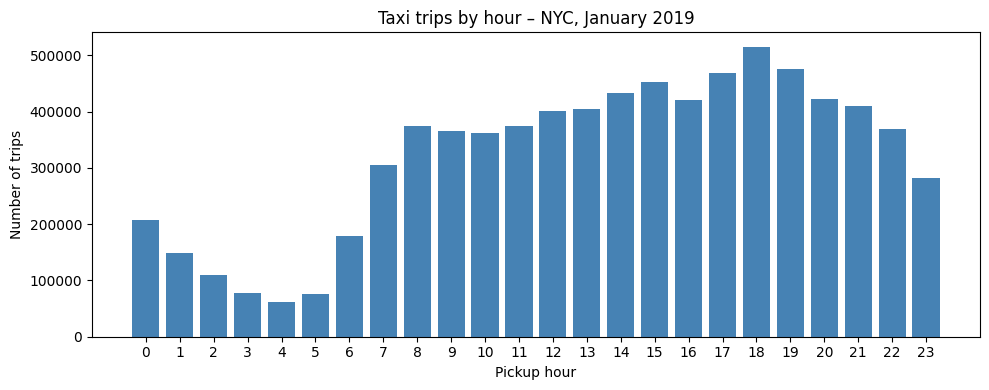

In [30]:
pdf_hours = df_hours.orderBy("hour").toPandas()

plt.figure(figsize=(10, 4))
plt.bar(pdf_hours["hour"], pdf_hours["count"], color="steelblue")
plt.xticks(range(24))
plt.xlabel("Pickup hour")
plt.ylabel("Number of trips")
plt.title("Taxi trips by hour – NYC, January 2019")
plt.tight_layout()
plt.show()

The curve looks like a wave : big hole between 3h and 5h, fast climb from 6h-7h with the commute, high all the day and then the peak at 18h-19h, and it goes down slowly until midnight.

> **Viz 2.** Pickups vs dropoffs by borough (Part 2, Q1)

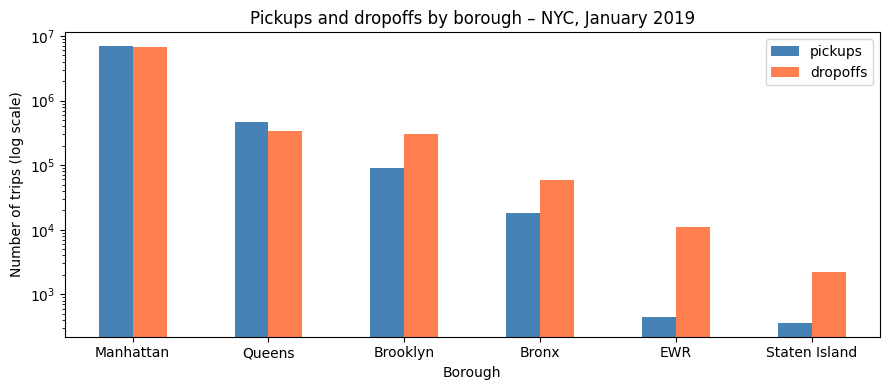

In [31]:
pdf_pu = df_joined.groupBy("PUBorough").count().withColumnRenamed("PUBorough", "Borough") \
    .withColumnRenamed("count", "pickups").toPandas()
pdf_do = df_joined.groupBy("DOBorough").count().withColumnRenamed("DOBorough", "Borough") \
    .withColumnRenamed("count", "dropoffs").toPandas()
pdf_boro = pdf_pu.merge(pdf_do, on="Borough", how="outer").fillna(0)
pdf_boro = pdf_boro[~pdf_boro["Borough"].isin(["Unknown", "N/A"])].set_index("Borough") \
    .sort_values("pickups", ascending=False)

ax = pdf_boro.plot.bar(figsize=(9, 4), color=["steelblue", "coral"], rot=0, logy=True)
ax.set_ylabel("Number of trips (log scale)")
ax.set_title("Pickups and dropoffs by borough – NYC, January 2019")
plt.tight_layout()
plt.show()

We need the log scale because Manhattan is 100 times above the other boroughs. It also shows the difference pickups/dropoffs in Brooklyn, Bronx and Staten Island (the coral bars are much higher than the blue ones) : people arrive there with a yellow taxi but they don't leave with one.

> **Viz 3.** January 2019 vs January 2025 (Part 2, Q7)

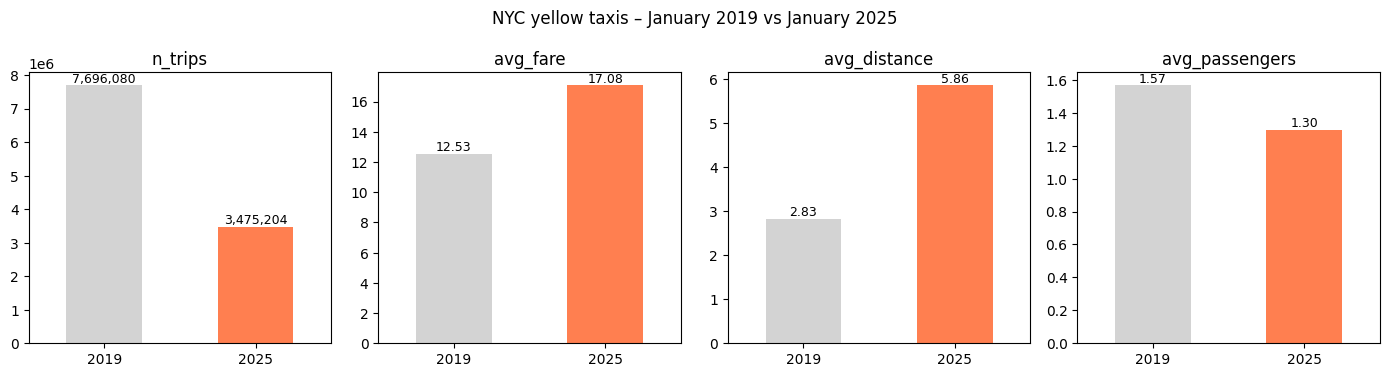

In [32]:
m2019 = df_trips.select(*metrics).toPandas().iloc[0]
m2025 = df_2025.select(*metrics).toPandas().iloc[0]
import pandas as pd
pdf_cmp = pd.DataFrame({"2019": m2019, "2025": m2025})

fig, axes = plt.subplots(1, 4, figsize=(14, 3.8))
for ax, m in zip(axes, ["n_trips", "avg_fare", "avg_distance", "avg_passengers"]):
    pdf_cmp.loc[m].plot.bar(ax=ax, color=["lightgray", "coral"], rot=0)
    ax.set_title(m)
    for i, v in enumerate(pdf_cmp.loc[m]):
        ax.text(i, v, f"{v:,.2f}" if m != "n_trips" else f"{int(v):,}", ha="center", va="bottom", fontsize=9)
plt.suptitle("NYC yellow taxis – January 2019 vs January 2025")
plt.tight_layout()
plt.show()

In 6 years the yellow taxi does 2 times less trips, but each trip is more expensive and with less people : the service became more individual and more expensive, and Uber took the short and shared trips.